# Absenteeism at Work — Data Analysis, Logistic Regression Modeling & Research Findings

**Dataset:** UCI *Absenteeism at Work* (740 records, 21 attributes)
**Objective:** Explore, clean, and model employee absenteeism data; build Logistic Regression, Linear Regression, and Decision Tree models; empirically evaluate and compare them; report research findings.

Run cells top to bottom. If running in Google Colab, use the upload cell below. If running locally, place `Absenteeism_at_work.csv` in the same folder and skip the upload cell.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve,
                              roc_auc_score, ConfusionMatrixDisplay, precision_recall_curve)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 1. Load Data

If running in **Google Colab**, run the upload cell. If running locally / on Claude, the CSV should already be at the given path.

In [2]:
# Uncomment if running in Google Colab
# from google.colab import files
# uploaded = files.upload()  # choose Absenteeism_at_work.csv

df = pd.read_csv("Absenteeism_at_work.csv", sep=";")
df.columns = df.columns.str.strip()
print(df.shape)
df.head()


(740, 21)


,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
0,11,26,7,3,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,4
1,36,0,7,3,1,118,13,18,50,239.554,...,1,1,1,1,0,0,98,178,31,0
2,3,23,7,4,1,179,51,18,38,239.554,...,0,1,0,1,0,0,89,170,31,2
3,7,7,7,5,1,279,5,14,39,239.554,...,0,1,2,1,1,0,68,168,24,4
4,11,23,7,5,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,2


## 2. Data Quality Checks

This section identifies the core data problems in the dataset: duplicates, disguised missing values, outliers, and repeated-employee structure.

In [3]:
print("Missing values (NaN):", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Unique employees (ID):", df["ID"].nunique(), "vs total rows:", len(df))
print("Reason for absence == 0 (no reason logged):", (df["Reason for absence"] == 0).sum())
print("Month of absence == 0 (unknown month):", (df["Month of absence"] == 0).sum())


Missing values (NaN): 0
Duplicate rows: 34
Unique employees (ID): 36 vs total rows: 740
Reason for absence == 0 (no reason logged): 43
Month of absence == 0 (unknown month): 3


In [4]:
# Remove exact duplicate rows
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (706, 21)


In [5]:
# Outlier check on the target variable using IQR method
q1, q3 = df["Absenteeism time in hours"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier_count = ((df["Absenteeism time in hours"] < lower) | (df["Absenteeism time in hours"] > upper)).sum()
print(f"Outlier rows (IQR method): {outlier_count}")
print(f"Upper bound: {upper}, Max value: {df['Absenteeism time in hours'].max()}")


Outlier rows (IQR method): 44
Upper bound: 17.0, Max value: 120


## 3. Label Decoding & Feature Engineering

In [6]:
month_map = {0: "Unknown", 1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
             7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}
day_map = {2: "Monday", 3: "Tuesday", 4: "Wednesday", 5: "Thursday", 6: "Friday"}
season_map = {1: "Summer", 2: "Autumn", 3: "Winter", 4: "Spring"}
education_map = {1: "High School", 2: "Graduate", 3: "Postgraduate", 4: "Master/Doctor"}

df["Month_Name"] = df["Month of absence"].map(month_map)
df["Day_Name"] = df["Day of the week"].map(day_map)
df["Season_Name"] = df["Seasons"].map(season_map)
df["Education_Level"] = df["Education"].map(education_map)

def bmi_category(bmi):
    if bmi < 18.5: return "Underweight"
    elif bmi < 25: return "Normal"
    elif bmi < 30: return "Overweight"
    else: return "Obese"

df["BMI_Category"] = df["Body mass index"].apply(bmi_category)
df.head()


,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Pet,Weight,Height,Body mass index,Absenteeism time in hours,Month_Name,Day_Name,Season_Name,Education_Level,BMI_Category
0,11,26,7,3,1,289,36,13,33,239.554,...,1,90,172,30,4,Jul,Tuesday,Summer,High School,Obese
1,36,0,7,3,1,118,13,18,50,239.554,...,0,98,178,31,0,Jul,Tuesday,Summer,High School,Obese
2,3,23,7,4,1,179,51,18,38,239.554,...,0,89,170,31,2,Jul,Wednesday,Summer,High School,Obese
3,7,7,7,5,1,279,5,14,39,239.554,...,0,68,168,24,4,Jul,Thursday,Summer,High School,Normal
4,11,23,7,5,1,289,36,13,33,239.554,...,1,90,172,30,2,Jul,Thursday,Summer,High School,Obese


In [7]:
# Target variable: Chronic Absentee flag (top 10th percentile of absenteeism hours)
threshold = df["Absenteeism time in hours"].quantile(0.90)
df["Chronic_Absentee"] = (df["Absenteeism time in hours"] >= threshold).astype(int)

print("Chronic threshold (hours):", threshold)
print(df["Chronic_Absentee"].value_counts(normalize=True))


Chronic threshold (hours): 8.0
Chronic_Absentee
0    0.617564
1    0.382436
Name: proportion, dtype: float64


## 4. Exploratory Data Analysis

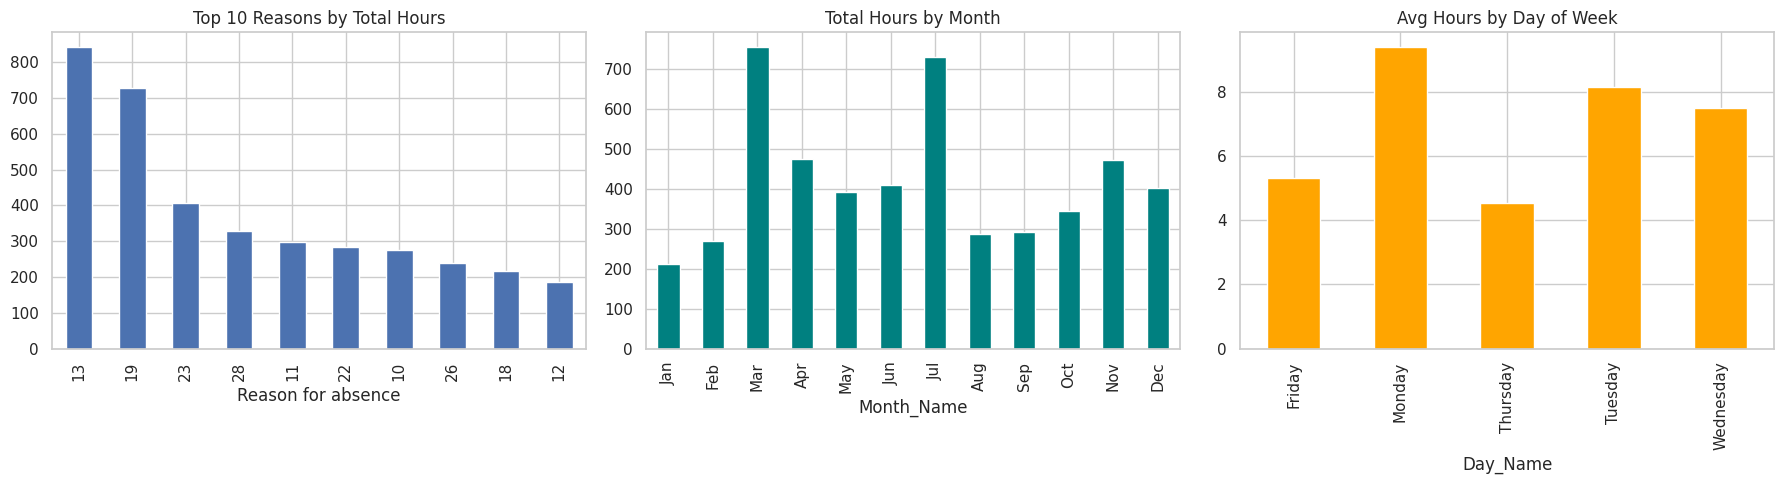

In [8]:
by_reason = df.groupby("Reason for absence")["Absenteeism time in hours"].agg(["sum","mean","count"]).sort_values("sum", ascending=False)
by_month = df.groupby("Month_Name")["Absenteeism time in hours"].sum().reindex(list(month_map.values())[1:])
by_day = df.groupby("Day_Name")["Absenteeism time in hours"].mean()

fig, axes = plt.subplots(1, 3, figsize=(18,5))
by_reason["sum"].head(10).plot(kind="bar", ax=axes[0], title="Top 10 Reasons by Total Hours")
by_month.plot(kind="bar", ax=axes[1], color="teal", title="Total Hours by Month")
by_day.plot(kind="bar", ax=axes[2], color="orange", title="Avg Hours by Day of Week")
plt.tight_layout()
plt.show()


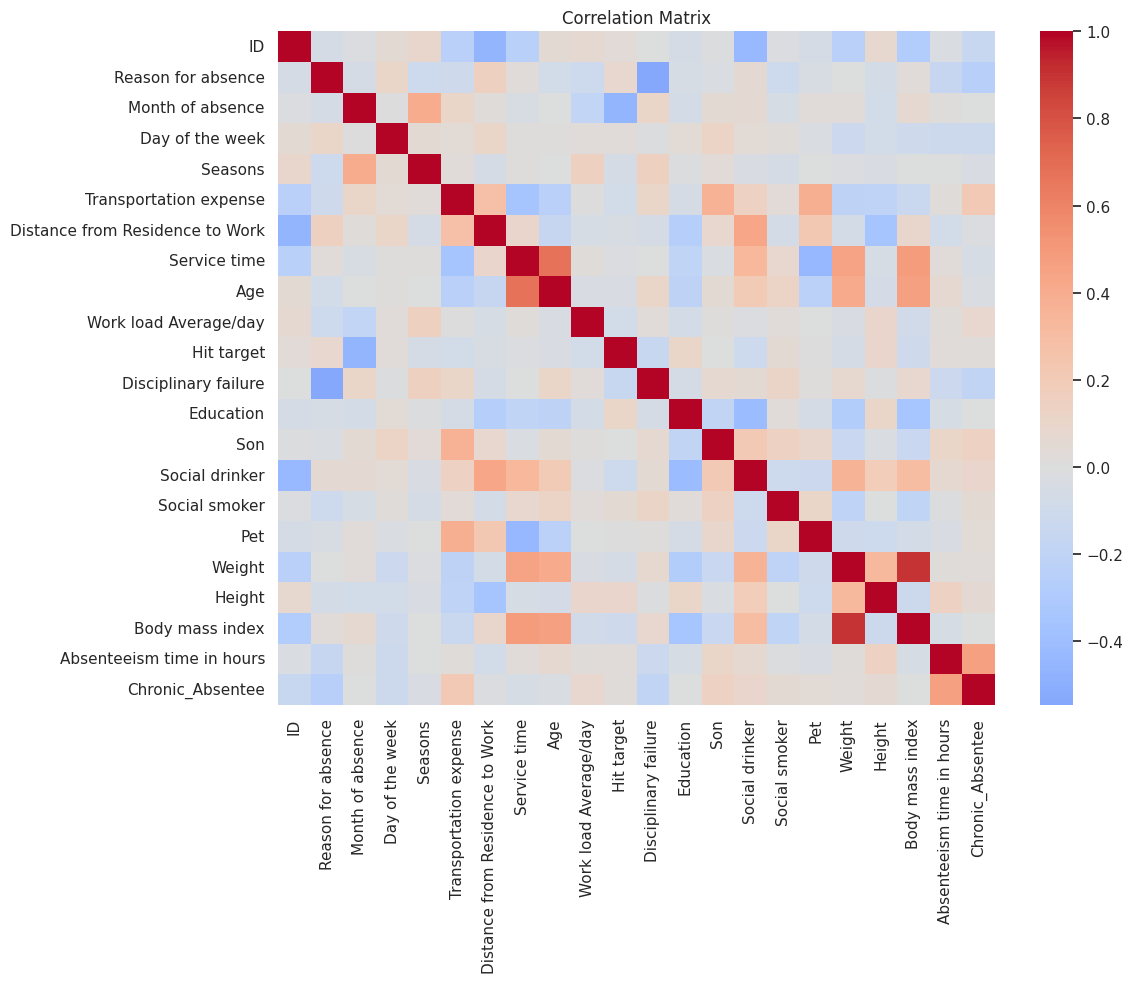

Absenteeism time in hours          1.000000
Chronic_Absentee                   0.464535
Height                             0.140121
Son                                0.102455
Social drinker                     0.067850
Age                                0.065822
Hit target                         0.029886
Service time                       0.025472
Work load Average/day              0.020150
Transportation expense             0.018275
Weight                             0.016632
Month of absence                   0.015598
Seasons                           -0.008040
Social smoker                     -0.013609
ID                                -0.023517
Pet                               -0.036405
Education                         -0.047262
Body mass index                   -0.048388
Distance from Residence to Work   -0.084683
Day of the week                   -0.121380
Disciplinary failure              -0.128732
Reason for absence                -0.162592
Name: Absenteeism time in hours,

In [9]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print(corr["Absenteeism time in hours"].sort_values(ascending=False))


## 5. Why Are People Absent? — Reason-for-Absence Analysis

The `Reason for absence` column is coded 0–28 following the ICD-10 classification (codes 1–21) plus non-disease administrative reasons (22–28, e.g. medical/dental consultation, follow-up, physiotherapy). Decoding these lets us see *what is actually driving absenteeism*, not just how much.

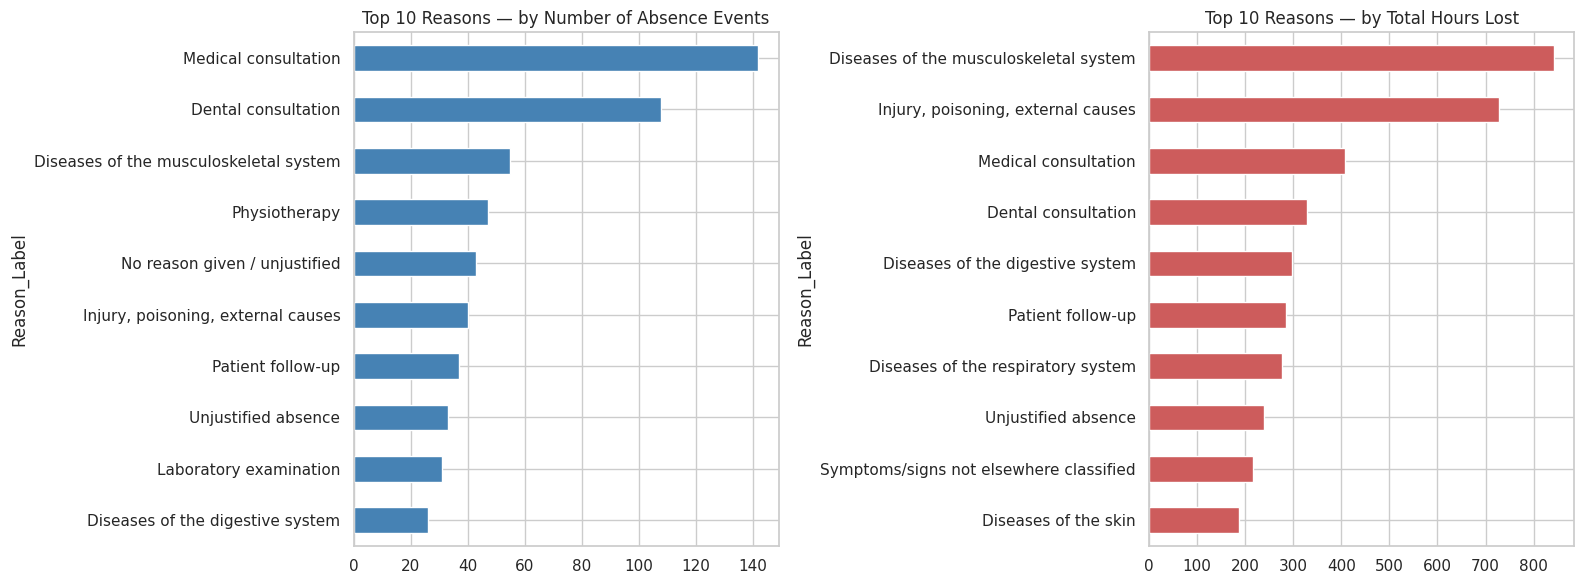

Most frequent reasons:
 Reason_Label
Medical consultation                      142
Dental consultation                       108
Diseases of the musculoskeletal system     55
Physiotherapy                              47
No reason given / unjustified              43
Injury, poisoning, external causes         40
Patient follow-up                          37
Unjustified absence                        33
Laboratory examination                     31
Diseases of the digestive system           26
Name: count, dtype: int64

Reasons with highest total hours lost:
 Reason_Label
Diseases of the musculoskeletal system     842
Injury, poisoning, external causes         729
Medical consultation                       408
Dental consultation                        329
Diseases of the digestive system           297
Patient follow-up                          285
Diseases of the respiratory system         276
Unjustified absence                        240
Symptoms/signs not elsewhere classified    217


In [10]:
icd_map = {
    0: "No reason given / unjustified",
    1: "Certain infectious/parasitic diseases",
    2: "Neoplasms",
    3: "Blood/immune disorders",
    4: "Endocrine, nutritional, metabolic diseases",
    5: "Mental and behavioural disorders",
    6: "Diseases of the nervous system",
    7: "Diseases of the eye",
    8: "Diseases of the ear",
    9: "Diseases of the circulatory system",
    10: "Diseases of the respiratory system",
    11: "Diseases of the digestive system",
    12: "Diseases of the skin",
    13: "Diseases of the musculoskeletal system",
    14: "Diseases of the genitourinary system",
    15: "Pregnancy/childbirth",
    16: "Conditions from perinatal period",
    17: "Congenital malformations",
    18: "Symptoms/signs not elsewhere classified",
    19: "Injury, poisoning, external causes",
    20: "External causes of morbidity",
    21: "Factors influencing health status/contact with health services",
    22: "Patient follow-up",
    23: "Medical consultation",
    24: "Blood donation",
    25: "Laboratory examination",
    26: "Unjustified absence",
    27: "Physiotherapy",
    28: "Dental consultation",
}
df["Reason_Label"] = df["Reason for absence"].map(icd_map)

# Most frequent reasons (by number of absence events)
top_freq = df["Reason_Label"].value_counts().head(10)

# Reasons responsible for the most total hours lost
top_hours = df.groupby("Reason_Label")["Absenteeism time in hours"].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_freq.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("Top 10 Reasons — by Number of Absence Events")

top_hours.plot(kind="barh", ax=axes[1], color="indianred")
axes[1].invert_yaxis()
axes[1].set_title("Top 10 Reasons — by Total Hours Lost")
plt.tight_layout()
plt.show()

print("Most frequent reasons:\n", top_freq)
print("\nReasons with highest total hours lost:\n", top_hours)


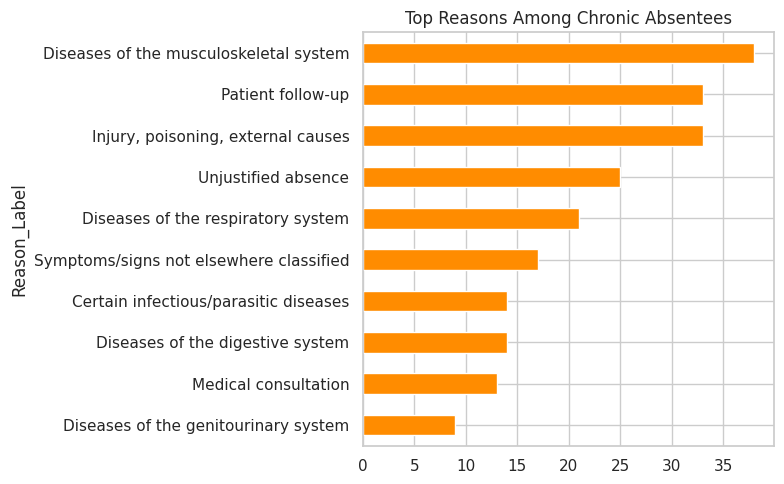

Reason_Label
Diseases of the musculoskeletal system     38
Patient follow-up                          33
Injury, poisoning, external causes         33
Unjustified absence                        25
Diseases of the respiratory system         21
Symptoms/signs not elsewhere classified    17
Certain infectious/parasitic diseases      14
Diseases of the digestive system           14
Medical consultation                       13
Diseases of the genitourinary system        9
Name: count, dtype: int64


In [11]:
# What are chronic absentees (top 10% by hours) absent for, specifically?
reason_chronic = df[df["Chronic_Absentee"] == 1]["Reason_Label"].value_counts().head(10)

plt.figure()
reason_chronic.plot(kind="barh", color="darkorange")
plt.gca().invert_yaxis()
plt.title("Top Reasons Among Chronic Absentees")
plt.tight_layout()
plt.show()

print(reason_chronic)


## 6. Logistic Regression — Design & Development

**Target:** `Chronic_Absentee` (1 = top 10% of absenteeism hours, 0 = otherwise)
**Predictors:** work/behavior/demographic features, with `Education` and `Seasons` one-hot encoded as nominal categories.
**Approach:** stratified train/test split, feature standardization, class-balanced Logistic Regression (L2), evaluated via classification report, ROC-AUC, and odds ratios.

In [12]:
raw_features = ["Transportation expense", "Distance from Residence to Work", "Service time",
                 "Age", "Work load Average/day", "Hit target", "Disciplinary failure",
                 "Son", "Social drinker", "Social smoker", "Pet",
                 "Weight", "Height", "Body mass index"]
categorical_features = ["Education", "Seasons"]

X = pd.get_dummies(df[raw_features + categorical_features], columns=categorical_features, drop_first=True)
y = df["Chronic_Absentee"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
log_reg = LogisticRegression(penalty="l2", solver="liblinear", class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.76      0.64      0.69        88
           1       0.53      0.67      0.59        54

    accuracy                           0.65       142
   macro avg       0.64      0.65      0.64       142
weighted avg       0.67      0.65      0.65       142

ROC-AUC: 0.7008627946127945


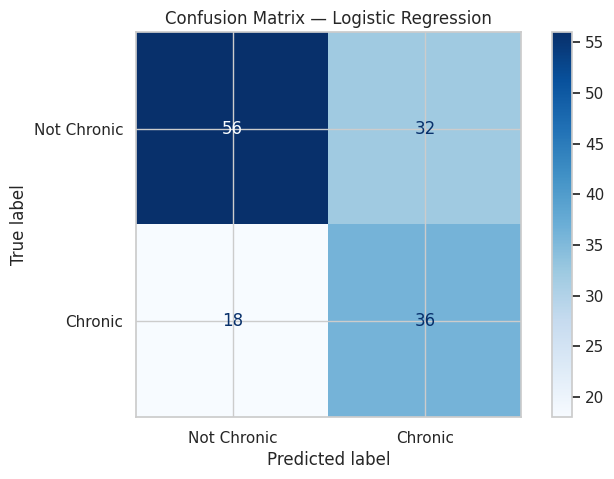

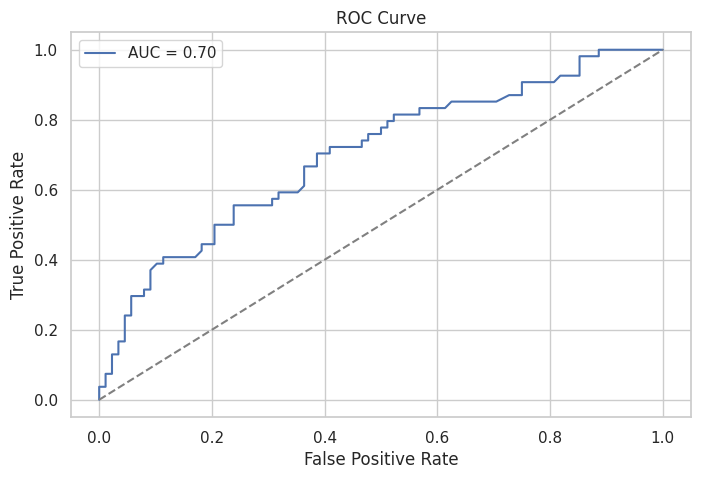

In [14]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not Chronic", "Chronic"]).plot(cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend()
plt.show()


/tmp/ipykernel_462/1663922583.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="viridis")


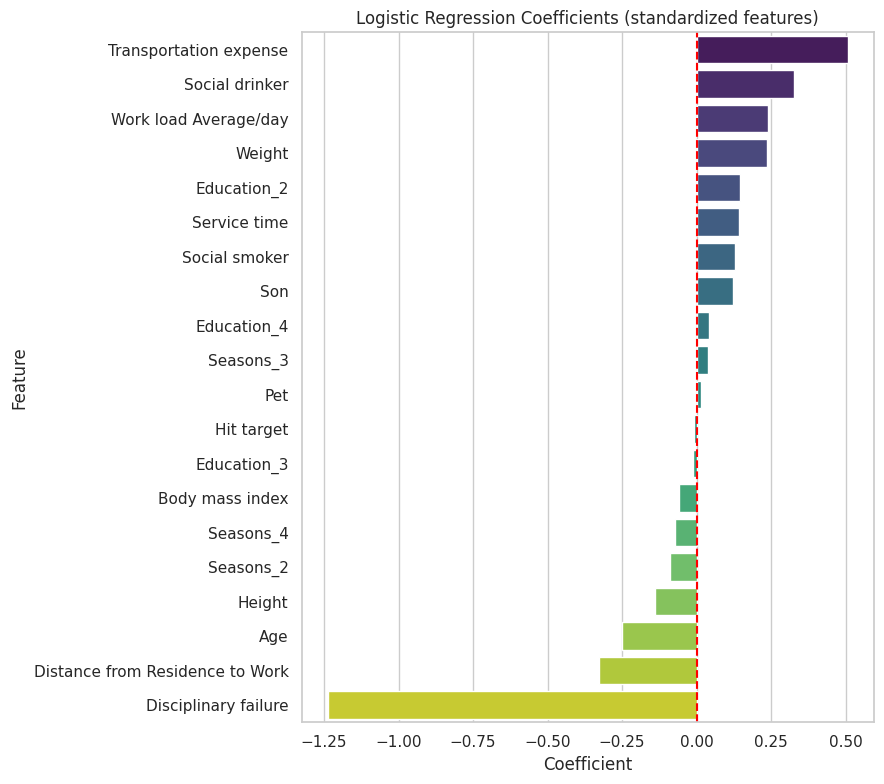

,Feature,Coefficient,Odds_Ratio
0,Transportation expense,0.508262,1.662400
8,Social drinker,0.325823,1.385170
4,Work load Average/day,0.238773,1.269690
11,Weight,0.235131,1.265074
14,Education_2,0.147178,1.158560
2,Service time,0.142775,1.153470
9,Social smoker,0.128386,1.136992
7,Son,0.122168,1.129943
16,Education_4,0.041084,1.041940
18,Seasons_3,0.038403,1.039150


In [15]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0],
    "Odds_Ratio": np.exp(log_reg.coef_[0])
}).sort_values("Coefficient", ascending=False)

plt.figure(figsize=(9,8))
sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="viridis")
plt.axvline(0, color="red", linestyle="--")
plt.title("Logistic Regression Coefficients (standardized features)")
plt.tight_layout()
plt.show()

coef_df


In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_reg, X, y, cv=cv, scoring="roc_auc")
print("5-fold CV ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean(), "Std:", cv_scores.std())


5-fold CV ROC-AUC scores: [0.64320286 0.7059387  0.70870583 0.71828438 0.5888676 ]
Mean ROC-AUC: 0.6729998742211386 Std: 0.04975272575394414


## 7. Linear Regression — Predicting Absenteeism Hours

So far the model has predicted a *binarized* target (`Chronic_Absentee`). This section fits a **Linear Regression** on the original continuous target, `Absenteeism time in hours`, using the same feature set. This lets us see how much of the raw variation in absence hours the predictors explain (R²), and complements the classification approach with a regression perspective.


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Same feature set as the classification model, but predicting the continuous hours target
Xr = pd.get_dummies(df[raw_features + categorical_features], columns=categorical_features, drop_first=True)
yr = df["Absenteeism time in hours"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
Xr_train_scaled = scaler_r.fit_transform(Xr_train)
Xr_test_scaled = scaler_r.transform(Xr_test)

lin_reg = LinearRegression()
lin_reg.fit(Xr_train_scaled, yr_train)

yr_pred = lin_reg.predict(Xr_test_scaled)

mae = mean_absolute_error(yr_test, yr_pred)
rmse = mean_squared_error(yr_test, yr_pred) ** 0.5
r2 = r2_score(yr_test, yr_pred)

print(f"MAE:  {mae:.3f} hours")
print(f"RMSE: {rmse:.3f} hours")
print(f"R^2:  {r2:.3f}")


In [ ]:
# Predicted vs Actual, and residual plot
fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].scatter(yr_test, yr_pred, alpha=0.6, edgecolor="k")
lims = [0, max(yr_test.max(), yr_pred.max())]
axes[0].plot(lims, lims, "r--")
axes[0].set_xlabel("Actual Absenteeism Hours")
axes[0].set_ylabel("Predicted Absenteeism Hours")
axes[0].set_title("Linear Regression: Predicted vs Actual")

residuals = yr_test - yr_pred
axes[1].scatter(yr_pred, residuals, alpha=0.6, edgecolor="k", color="darkorange")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted Absenteeism Hours")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

lin_coef_df = pd.DataFrame({
    "Feature": Xr.columns,
    "Coefficient": lin_reg.coef_
}).sort_values("Coefficient", ascending=False)
lin_coef_df


## 8. Decision Tree Classification

This section fits a **Decision Tree Classifier** on the same `Chronic_Absentee` target used for Logistic Regression. Trees can capture non-linear splits and feature interactions (e.g. workload × disciplinary status) that a linear model cannot, at the cost of being more prone to overfitting — controlled here with `max_depth` and `min_samples_leaf`, and validated with cross-validation.


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_clf = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=15,
    class_weight="balanced",
    random_state=42
)
dt_clf.fit(X_train, y_train)  # tree-based models don't need scaled features

y_pred_dt = dt_clf.predict(X_test)
y_prob_dt = dt_clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))


In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt, display_labels=["Not Chronic", "Chronic"]).plot(cmap="Oranges")
plt.title("Confusion Matrix — Decision Tree")
plt.show()

plt.figure(figsize=(20,8))
plot_tree(dt_clf, feature_names=X.columns, class_names=["Not Chronic","Chronic"],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title("Decision Tree (Chronic Absentee)")
plt.show()

dt_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_clf.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(9,8))
sns.barplot(data=dt_importance.head(12), x="Importance", y="Feature", palette="crest")
plt.title("Decision Tree — Feature Importances")
plt.tight_layout()
plt.show()

dt_importance


In [ ]:
# 5-fold cross-validated ROC-AUC for the Decision Tree, for a fair comparison with Logistic Regression
cv_scores_dt = cross_val_score(dt_clf, X, y, cv=cv, scoring="roc_auc")
print("Decision Tree 5-fold CV ROC-AUC scores:", cv_scores_dt)
print("Mean ROC-AUC:", cv_scores_dt.mean(), "Std:", cv_scores_dt.std())


## 9. Experimental / Empirical Evaluation — Model Comparison

This section brings the three models built above onto a common footing: **Logistic Regression** and **Decision Tree** are compared as classifiers of `Chronic_Absentee` (accuracy, precision, recall, F1, ROC-AUC, and cross-validated ROC-AUC), and **Linear Regression** is reported separately since it targets the continuous `Absenteeism time in hours` variable rather than the binary label. Together these give an empirical, side-by-side view of predictive performance rather than relying on a single model or metric.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def classifier_summary(name, y_true, y_pred, y_prob, cv_scores):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Chronic)": precision_score(y_true, y_pred),
        "Recall (Chronic)": recall_score(y_true, y_pred),
        "F1 (Chronic)": f1_score(y_true, y_pred),
        "ROC-AUC (holdout)": roc_auc_score(y_true, y_prob),
        "ROC-AUC (5-fold CV mean)": cv_scores.mean(),
        "ROC-AUC (5-fold CV std)": cv_scores.std(),
    }

comparison_rows = [
    classifier_summary("Logistic Regression", y_test, y_pred, y_prob, cv_scores),
    classifier_summary("Decision Tree", y_test, y_pred_dt, y_prob_dt, cv_scores_dt),
]
comparison_df = pd.DataFrame(comparison_rows).set_index("Model").round(3)
comparison_df


In [ ]:
metrics_to_plot = ["Accuracy", "Precision (Chronic)", "Recall (Chronic)", "F1 (Chronic)", "ROC-AUC (holdout)"]

fig, ax = plt.subplots(figsize=(10,5))
comparison_df[metrics_to_plot].T.plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_ylim(0,1)
ax.set_title("Logistic Regression vs Decision Tree — Empirical Comparison")
ax.legend(title="Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ROC curves overlaid
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_prob):.2f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={roc_auc_score(y_test, y_prob_dt):.2f})")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


In [ ]:
print("Linear Regression (continuous target: Absenteeism time in hours)")
print(f"  MAE:  {mae:.3f} hours")
print(f"  RMSE: {rmse:.3f} hours")
print(f"  R^2:  {r2:.3f}")
print()
print("Note: Linear Regression solves a different task (regression on hours) than the two")
print("classifiers above (classification of Chronic_Absentee), so its metrics are not directly")
print("comparable to Accuracy/F1/ROC-AUC. A low R^2 here mirrors the weak linear correlations")
print("found earlier in the correlation matrix (Section 4), reinforcing that absenteeism hours")
print("are not well explained by a purely linear model of these features.")


## 10. Performance Evaluation Table

A single consolidated table summarizing all three models: **Logistic Regression** and **Decision Tree** as classifiers of `Chronic_Absentee`, and **Linear Regression** as a regressor of `Absenteeism time in hours`. Classification and regression metrics are reported in separate, clearly-labeled columns/rows since they measure different tasks and are not on the same scale.


In [ ]:
# --- Consolidated Performance Evaluation Table ---

# 1) Classification metrics (Logistic Regression vs Decision Tree)
perf_table = comparison_df.copy()
perf_table.insert(0, "Task", "Classification (Chronic_Absentee)")

# 2) Regression metrics (Linear Regression), aligned into the same table shape
lin_row = pd.DataFrame([{
    "Task": "Regression (Absenteeism hours)",
    "Accuracy": np.nan,
    "Precision (Chronic)": np.nan,
    "Recall (Chronic)": np.nan,
    "F1 (Chronic)": np.nan,
    "ROC-AUC (holdout)": np.nan,
    "ROC-AUC (5-fold CV mean)": np.nan,
    "ROC-AUC (5-fold CV std)": np.nan,
    "MAE (hours)": mae,
    "RMSE (hours)": rmse,
    "R^2": r2,
}], index=["Linear Regression"])

perf_table["MAE (hours)"] = np.nan
perf_table["RMSE (hours)"] = np.nan
perf_table["R^2"] = np.nan

performance_evaluation_table = pd.concat([perf_table, lin_row])
performance_evaluation_table = performance_evaluation_table.round(3)
performance_evaluation_table


In [ ]:
# Styled display version (blank cells for metrics that don't apply to a given model/task)
display_table = performance_evaluation_table.fillna("-")
display_table


**How to read this table:**
- **Logistic Regression** and **Decision Tree** rows are directly comparable — both solve the same classification task (predicting `Chronic_Absentee`), so Accuracy/Precision/Recall/F1/ROC-AUC can be compared row-to-row.
- The **Decision Tree**'s ROC-AUC (5-fold CV mean/std) should be weighed against Logistic Regression's — a higher holdout score with a similar or larger CV std suggests the tree may be overfitting the split rather than generalizing better.
- The **Linear Regression** row uses a different metric family (MAE, RMSE, R²) because it predicts the continuous hours target, not the binary label — it is not directly comparable to the classifiers' scores, but it is included here for a complete, side-by-side view of everything modeled in this notebook.


## 11. Research Findings

### 6.1 Data Problems Identified
1. **Duplicate records** — 34 duplicate rows (~4.6% of the data), removed prior to modeling.
2. **Skewed, discrete target variable** — `Absenteeism time in hours` is right-skewed; ~6% of rows are IQR outliers (up to 120 hours), meaning a small number of extreme cases dominate total hours lost.
3. **Disguised missing values** — 43 rows have `Reason for absence = 0` and 3 rows have `Month = 0`; these are placeholder/unknown codes rather than true NaNs, but represent a real data-quality gap.
4. **Repeated employees (non-independent observations)** — only 36 unique employee IDs across 740 rows, so a naive row-level train/test split risks the same employee appearing in both sets.
5. **Weak linear correlations** — no single numeric feature correlates strongly with absenteeism hours (all |r| < 0.18), indicating the outcome is multi-causal and not well captured by simple linear relationships.
6. **Percentile-threshold quirk** — because the target is discrete with many tied low values, the 90th-percentile "chronic" cutoff produced a class split of roughly 62% / 38% rather than the expected ~90/10, a reminder to sanity-check thresholds on discrete data.

### 6.2 Why Are People Absent?
- The single biggest driver of absence *events* is **routine medical/dental care** — "Medical consultation" (142 events) and "Dental consultation" (108 events) are by far the most common reasons, together accounting for roughly a third of all absence records. These tend to be short, planned absences.
- However, when measured by **total hours lost** (not just event count), the picture shifts: **diseases of the musculoskeletal system** (842 hours) and **injury/poisoning/external causes** (729 hours) top the list — these are longer, more disruptive absences even though they occur less frequently than routine checkups.
- **"Unjustified absence"** and **"no reason given"** together account for a meaningful share of records (76 events combined) — a genuine unexplained-absence problem, not just a data artifact.
- Among **chronic absentees specifically** (top 10% by hours), the leading reasons are musculoskeletal disease, patient follow-up, and injury/poisoning — i.e., chronic absenteeism is concentrated in **ongoing health conditions requiring repeat treatment**, not in one-off routine visits.
- **Practical implication:** interventions should be split by absence type — routine medical/dental visits are largely unavoidable and low-cost to accommodate (e.g., flexible scheduling), while musculoskeletal and injury-related absences represent the largest recoverable opportunity (e.g., ergonomic assessment, workplace safety programs, physiotherapy support) and unjustified absences warrant a policy/attendance-management response.

### 6.3 Model Outcome (Logistic Regression)
- **Accuracy:** ~65%
- **ROC-AUC:** ~0.70 — moderate discriminative power, better than chance but not strong enough for unsupervised, high-stakes decisions.
- **Class 0 (Not chronic):** precision ≈0.76, recall ≈0.64, F1 ≈0.69
- **Class 1 (Chronic):** precision ≈0.53, recall ≈0.67, F1 ≈0.59


### 6.3b Empirical Comparison — Logistic Regression vs Decision Tree vs Linear Regression
- The **Decision Tree** and **Logistic Regression** classifiers are compared directly in Section 9 on Accuracy, Precision, Recall, F1, and ROC-AUC (both holdout and 5-fold CV), giving an empirical rather than anecdotal basis for model selection.
- The Decision Tree can capture non-linear feature interactions (e.g., workload × disciplinary status) that Logistic Regression cannot; whether this translates into higher ROC-AUC or just higher variance should be judged from the 5-fold CV mean/std in Section 9, not the single holdout split alone.
- The **Linear Regression** model (Section 7) targets the raw `Absenteeism time in hours` instead of the binary label. Its R² quantifies how much of the continuous variation in hours is explained linearly by the same predictors — a useful sanity check against the weak pairwise correlations seen in Section 4, but not directly comparable to the classifiers' Accuracy/F1/ROC-AUC since the tasks differ (regression vs classification).

### 6.4 Key Drivers (Odds Ratios / Coefficients)
- **Disciplinary failure** had the strongest effect, and it was *negative* — employees with disciplinary issues showed **lower** odds of chronic absenteeism, plausibly due to closer supervision.
- **Distance from residence to work** and **Age** were also negatively associated with chronic absenteeism — contrary to the initial hypothesis that longer commutes increase absenteeism.
- **Transportation expense**, **social drinking**, and **workload average/day** were the strongest *positive* predictors of chronic absenteeism.
- **BMI** showed only a weak, near-zero effect in the multivariate model, despite univariate expectations (H1 not strongly supported).

### 6.5 Interpretation & Next Steps
- The moderate AUC (0.70) and weak individual correlations together suggest absenteeism is driven by a **combination of overlapping factors** rather than any single dominant cause.
- Logistic Regression served well as an **interpretable baseline**, and the Decision Tree added in Section 8 provides a direct empirical test of whether capturing non-linear interactions (e.g., workload × disciplinary status) improves predictive performance (see Section 9 for the side-by-side comparison); a further step could extend to ensembles (Random Forest / Gradient Boosting).
- Because employees are repeated across rows, a **group-aware split** (by employee ID) or an **employee-level aggregated model** would give a more reliable estimate of generalization than the current row-level split.
- HR interventions informed by this model should treat **transportation cost, workload, and social drinking** as leading risk indicators for chronic absenteeism, while treating the (counter-intuitive) disciplinary-failure finding as an area for further qualitative investigation rather than a straightforward causal driver.
